In [1]:
import numpy as np
import emcee
def log_likelihood(theta, x, y, cov, kernel_func, **kwargs):
    l, sigma_f = np.exp(theta)
    K = kernel_func(x, x, [l, sigma_f], **kwargs) 
    A = K + cov + 1e-8 * np.eye(len(x))
    try:
        L = np.linalg.cholesky(A)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
        return -0.5 * y @ alpha - np.sum(np.log(np.diag(L)))
    except np.linalg.LinAlgError:
        return -np.inf

def log_probability(theta, x, y, cov, kernel_func, **kwargs):
    log_l, log_sf = theta
    if not (-10 < log_l < 10) or not (-10 < log_sf < 10):
        return -np.inf
    return log_likelihood(theta, x, y, cov, kernel_func, **kwargs)

def run_mcmc(x, y, cov, kernel_func, n_walkers=32, n_steps=2000, **kwargs):
    ndim = 2 # l, sigma_f
    p0_l = np.log((x.max() - x.min()) / 2)
    p0_sf = np.log(np.std(y))
    p0 = np.random.normal([p0_l, p0_sf], 0.1, (n_walkers, ndim))
    
    sampler = emcee.EnsembleSampler(
        n_walkers, ndim, log_probability, 
        args=(x, y, cov, kernel_func), 
        kwargs=kwargs 
    )
    sampler.run_mcmc(p0, n_steps, progress=True)
    discard = int(n_steps * 0.2)
    return sampler.get_chain(discard=discard, flat=True)

In [2]:
import numpy as np
import utils
import matplotlib.pyplot as plt
import corner
import pandas as pd

z_plot = np.linspace(0.005, 2.3, 200)
NU = 2.5

sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
mB_obs = sn_df['m_b_corr'].values
mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")

Running MCMC for Matérn 5/2...


100%|██████████| 2000/2000 [5:18:26<00:00,  9.55s/it]  


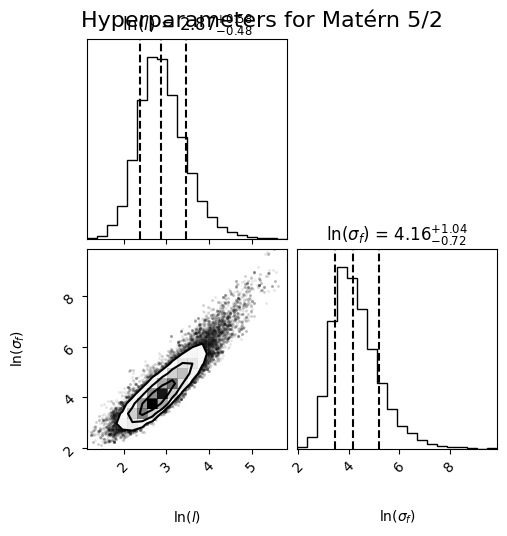

In [ ]:
print("Running MCMC ...")
theta_samples = run_mcmc(
    np.log10(z_sn), mB_obs, mB_cov, 
    utils.matern_kernel, 
    nu=NU
)

fig = corner.corner(
    theta_samples, 
    labels=[r"$\ln(l)$", r"$\ln(\sigma_f)$"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True
)
# fig.suptitle("Hyperparameters for Matérn 5/2", fontsize=16)
plt.show()

In [3]:
# np.save("output/theta_samples_52.npy", theta_samples)
theta_samples = np.load("output/theta_samples_52.npy")
theta_samples = np.exp(theta_samples) 

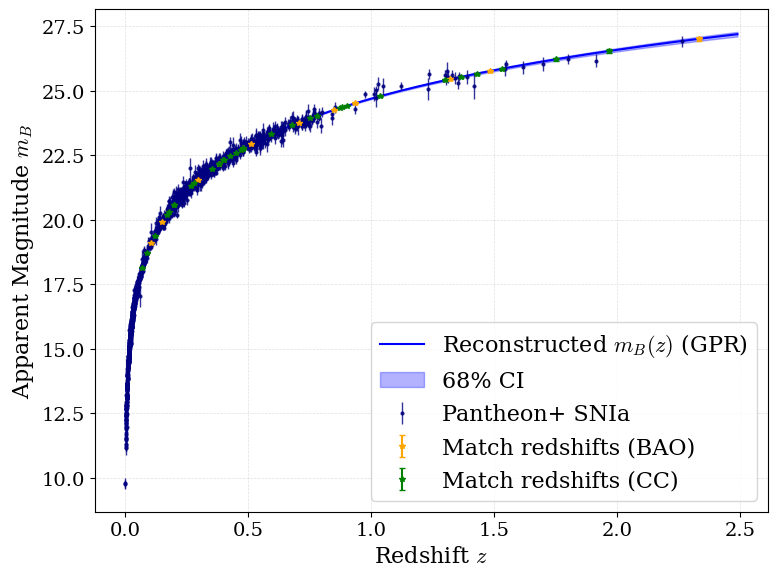

In [4]:
import utils
z_plot = np.linspace(0.05, max(z_sn) * 1.1, 1000)
mB_pred_mean, mB_pred_cov = utils.predict_marginalized(
    np.log10(z_sn), mB_obs, mB_cov, np.log10(z_plot), 
    utils.matern_kernel, 
    theta_samples, 
    nu=NU 
)
mB_pred_std = np.sqrt(np.diag(mB_pred_cov))
np.save('output/mB_pred_mean.npy', mB_pred_mean)
np.save('output/mB_pred_cov.npy', mB_pred_cov)

z_bao, _, _ = np.loadtxt('data/bao_data.dat', unpack=True)
mB_baomatch_mean, mB_baomatch_cov = utils.predict_marginalized(
    np.log10(z_sn), mB_obs, mB_cov, np.log10(z_bao), 
    utils.matern_kernel, 
    theta_samples, 
    nu=NU
)
np.save('output/mB_baomatch_mean.npy', mB_baomatch_mean)
np.save('output/mB_baomatch_cov.npy', mB_baomatch_cov)
mB_baomatch_std = np.sqrt(np.diag(mB_baomatch_cov))

z_cc, _, _ = np.loadtxt('data/cc.txt', unpack=True)
mB_ccmatch_mean, mB_ccmatch_cov = utils.predict_marginalized(
    np.log10(z_sn), mB_obs, mB_cov, np.log10(z_cc), 
    utils.matern_kernel, 
    theta_samples, 
    nu=NU 
)
mB_ccmatch_std = np.sqrt(np.diag(mB_ccmatch_cov))
np.save('output/mB_ccmatch_mean.npy', mB_ccmatch_mean)
np.save('output/mB_ccmatch_cov.npy', mB_ccmatch_cov)

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 14
})

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(z_plot, mB_pred_mean, label=r'Reconstructed $m_B(z)$ (GPR)', color='blue')



ax.fill_between(z_plot, mB_pred_mean - mB_pred_std, mB_pred_mean + mB_pred_std, color='blue', alpha=0.3, label=r'68% CI')

ax.errorbar(z_sn, mB_obs, np.sqrt(np.diag(mB_cov)), fmt='o', label='Pantheon+ SNIa',
            capsize=0, ms=2, elinewidth=1, color='navy', alpha=0.8)

ax.errorbar(z_bao, mB_baomatch_mean, mB_baomatch_std, fmt='*', label='Match redshifts (BAO)',
            markersize=4, capsize=2, linestyle='none', color='orange') 

ax.errorbar(z_cc, mB_ccmatch_mean, mB_ccmatch_std, fmt='*', label='Match redshifts (CC)',
            markersize=4, capsize=2, linestyle='none', color='g') 

ax.set_xlabel(r'Redshift $z$', fontsize=16)
ax.set_ylabel(r'Apparent Magnitude $m_B$', fontsize=16)

ax.legend(loc='best', frameon=True, fontsize=16)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('fig/mB_reconstruction_GPR_.pdf', bbox_inches='tight')
plt.show()



Processing prior: Planck2018MB0


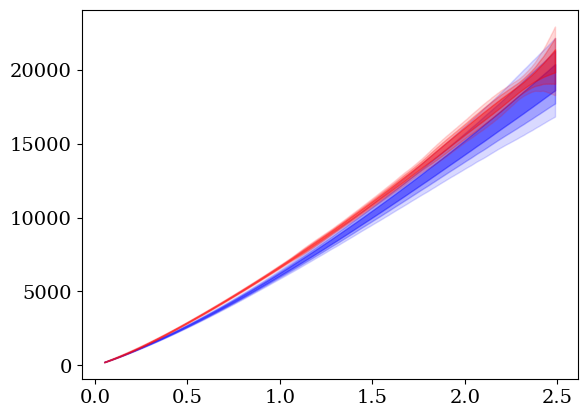

chi2: 42597.24, p-value: 0.0000
Number of BAO points: 11


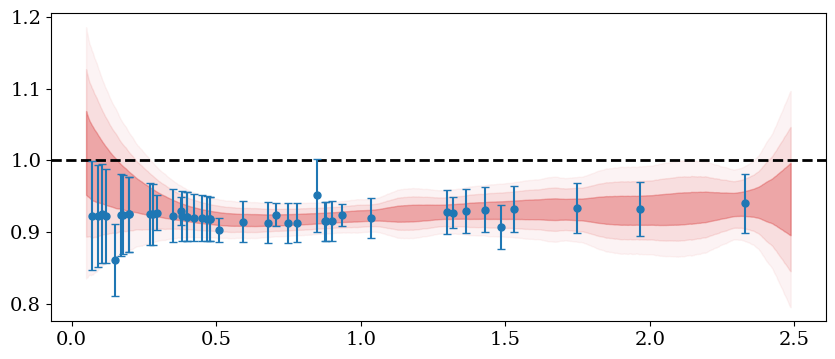


Processing prior: Planck2018MB23


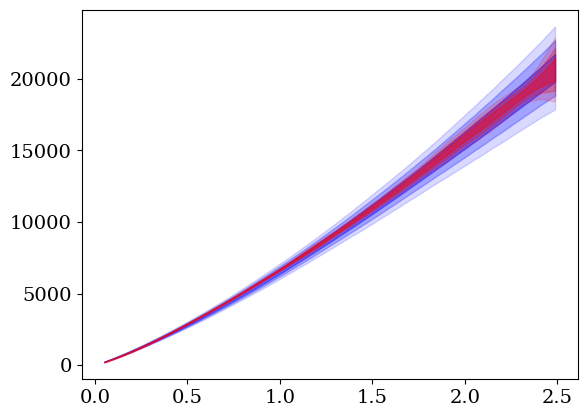

chi2: 2361.91, p-value: 0.0000
Number of BAO points: 11


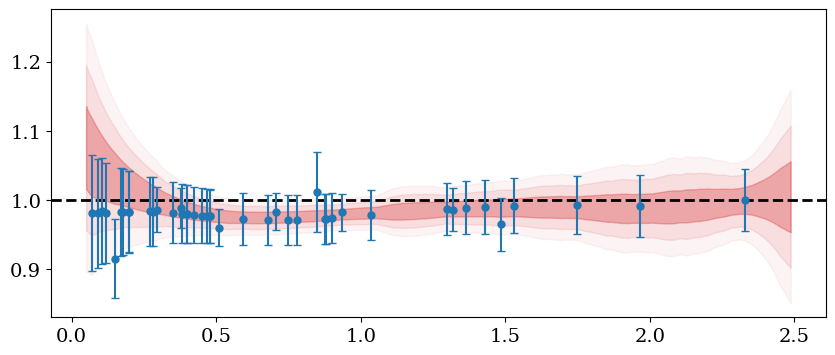

In [6]:
priors = [
        {"name":"Planck2018MB0", "label":"Planck2018+$M_B^\\mathrm{SH0ES}$", "MB": -19.253, "MB_err": 0.027, "rd": 147.09, "rd_err": 0.26},
        # {"name":"Planck2018MB23", "label":"Planck2018+$M_B^\\text{B23}$", "MB": -19.396, "MB_err": 0.016, "rd": 147.09, "rd_err": 0.26},
        {"name":"Planck2018MB23", "label":"Planck2018+$M_B^\\mathrm{??}$", "MB": -19.384, "MB_err": 0.052, "rd": 147.09, "rd_err": 0.26},
        # {"name":"Planck2018MB23", "label":"Planck2018+$M_B^\\mathrm{??}$", "MB": -19.42, "MB_err": 0.052, "rd": 147.09, "rd_err": 0.26},
]
z_plot = np.linspace(0.05, max(z_sn) * 1.1, 1000)
n_MC = 1000

z_da, da, da_std = np.loadtxt("output/da_summary.txt", unpack=True)
da_cov = np.load('output/da_cov.npy')
da_theta_samples = np.load("output/da_theta_samples.npy")
sigma0 = 1e-4
z_final  = np.concatenate([[0.0], z_da])
da_final = np.concatenate([[0.0], da])
cov_final = np.zeros((len(z_final), len(z_final)))
cov_final[1:, 1:] = da_cov
cov_final[0, 0]   = sigma0**2

DA_mean, DA_cov = utils.predict_marginalized(z_final, da_final, cov_final, z_plot, utils.matern_kernel, np.exp(da_theta_samples), nu = 1.5)
DA_samples = np.random.multivariate_normal(DA_mean, DA_cov, size=n_MC)

mB_samples = np.random.multivariate_normal(mB_pred_mean, mB_pred_cov, size=n_MC)


for prior in priors:
        MB = prior["MB"]; MB_err = prior["MB_err"]
        rd = prior["rd"]; rd_err = prior["rd_err"]
        print(f"\nProcessing prior: {prior['name']}")

        MB_samples = np.random.normal(MB, MB_err, n_MC)

        DL_samples = 10**((mB_samples - MB_samples[:, np.newaxis] - 25) / 5)
        DL_mean = np.mean(DL_samples, axis=0)
        DL_err = 0.5 * (np.percentile(DL_samples, 84, axis=0) - np.percentile(DL_samples, 16, axis=0))
        for sigma, alpha_fill, label_fill in zip([1, 2, 3], [0.4, 0.25, 0.15],[r'68% CI ($\pm 1\sigma$)', r'95% CI ($\pm 2\sigma$)', r'99.7% CI ($\pm 3\sigma$)']):
                plt.fill_between(z_plot,
                        (DL_mean - sigma * DL_err),
                        (DL_mean + sigma * DL_err),
                        color='blue', alpha=alpha_fill, label=label_fill)
            
        DA_mean, DA_cov = utils.predict_marginalized(z_final, da_final, cov_final, z_plot, utils.matern_kernel, np.exp(da_theta_samples), nu = 1.5)
        DA_samples = np.random.multivariate_normal(DA_mean, DA_cov, size=n_MC) #从gpr中采样nMC条曲线，从而得到误差
        DA_mean = np.mean(DA_samples, axis=0)
        DA_err = 0.5 * (np.percentile(DA_samples, 84, axis=0) - np.percentile(DA_samples, 16, axis=0))
        DL_down_samples = DA_samples*(1+z_plot)**2
        DL_down_mean = DA_mean*(1+z_plot)**2
        DL_down_mean_err = DA_err*(1+z_plot)**2
        for sigma, alpha_fill, label_fill in zip([1, 2, 3], [0.4, 0.25, 0.15],[r'68% CI ($\pm 1\sigma$)', r'95% CI ($\pm 2\sigma$)', r'99.7% CI ($\pm 3\sigma$)']):
                plt.fill_between(z_plot,
                        (DL_down_mean - sigma * DL_down_mean_err),
                        (DL_down_mean + sigma * DL_down_mean_err),
                        color='red', alpha=alpha_fill, label=label_fill)
        plt.show()

        eta_mean = DL_mean/DL_down_mean
        eta_err = eta_mean *np.sqrt((DA_err/DA_mean)**2+(DL_down_mean_err/DL_down_mean)**2)
        plt.figure(figsize=(10,4))
        for sigma, alpha_fill, label_fill in zip([1, 2, 3], [0.3, 0.1, 0.05],[r'68% CI ($\pm 1\sigma$)', r'95% CI ($\pm 2\sigma$)', r'99.7% CI ($\pm 3\sigma$)']):
                plt.fill_between(z_plot,
                        (eta_mean - sigma * eta_err),
                        (eta_mean + sigma * eta_err),
                        color='#d62728', alpha=alpha_fill, label=label_fill)
        plt.axhline(1.0, color='black', linestyle='--', linewidth=2, label=r'CDDR ($\eta=1$)')

        DL_samples_at_baocc = np.array([np.interp(z_da, z_plot, sample) for sample in DL_samples])
        DL_mean_at_baocc= np.mean(DL_samples_at_baocc, axis=0)
        DL_err_at_baocc = 0.5 * (np.percentile(DL_samples_at_baocc, 84, axis=0) - np.percentile(DL_samples_at_baocc, 16, axis=0))

        DL_down_samples_at_baocc = np.array([np.interp(z_da, z_plot, sample) for sample in DL_down_samples])
        DL_down_mean_at_baocc= np.mean(DL_down_samples_at_baocc, axis=0)
        DL_down_err_at_baocc = 0.5 * (np.percentile(DL_down_samples_at_baocc, 84, axis=0) - np.percentile(DL_down_samples_at_baocc, 16, axis=0))
        
        eta_match = DL_mean_at_baocc / (da*(1+z_da)**2)
        eta_match_std = np.abs(eta_match) * np.sqrt((da_std / da)**2 + (DL_err_at_baocc / DL_mean_at_baocc)**2)
        chi2_val, p_val = utils.eta_chi2(eta_mean, eta_err)
        print(f"chi2: {chi2_val:.2f}, p-value: {p_val:.4f}")
        print(f"Number of BAO points: {len(z_bao)}")
        plt.errorbar(z_da, eta_match, yerr=eta_match_std, fmt='o', label=r'$\eta(z_\mathrm{BAO})$', color="#1f77b4", capsize=3, markersize=5)
        plt.show()


In [55]:
print(DL_mean[0:10])
print(DL_down_mean[0:10])

[225.0489731  236.36936987 247.72340133 259.11164435 270.53390426
 281.9906234  293.48162596 305.00722166 316.5672088  328.16178033]
[210.78686482 221.81320265 232.88912104 244.01144725 255.17457811
 266.37764862 277.62405861 288.90772002 300.22915704 311.58509801]


(1000, 1000)


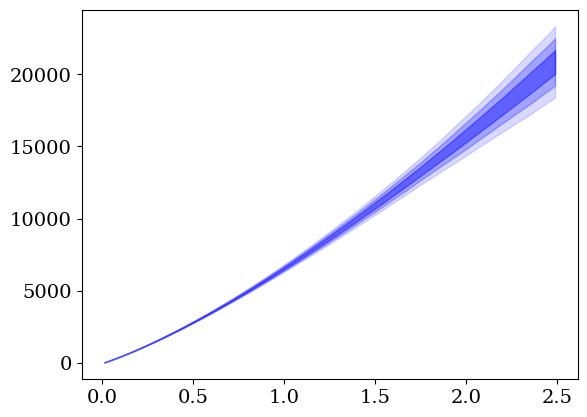

In [23]:
print(DL_samples.shape)
MB_samples = np.random.normal(-19.396, 0.016, n_MC)
DL_samples = 10**((mB_samples - MB_samples[:, np.newaxis] - 25) / 5)
DL_mean = np.mean(DL_samples, axis=0)
DL_err = 0.5 * (np.percentile(DL_samples, 84, axis=0) - np.percentile(DL_samples, 16, axis=0))
for sigma, alpha_fill, label_fill in zip([1, 2, 3], [0.4, 0.25, 0.15],[r'68% CI ($\pm 1\sigma$)', r'95% CI ($\pm 2\sigma$)', r'99.7% CI ($\pm 3\sigma$)']):
        plt.fill_between(z_plot,
                (DL_mean - sigma * DL_err),
                (DL_mean + sigma * DL_err),
                color='blue', alpha=alpha_fill, label=label_fill)

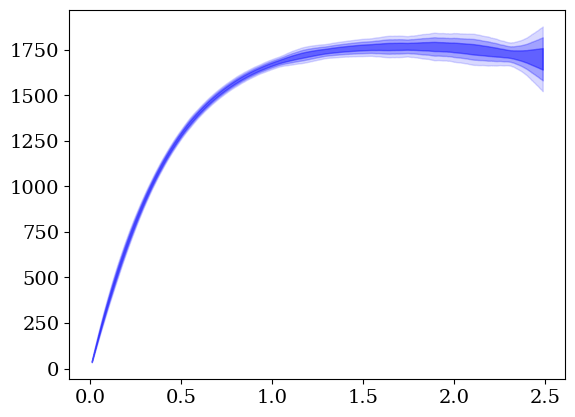

In [24]:
DA_mean, DA_cov = utils.predict_marginalized(z_final, da_final, cov_final, z_plot, utils.matern_kernel, np.exp(da_theta_samples), nu = 1.5)
DA_samples = np.random.multivariate_normal(DA_mean, DA_cov, size=n_MC) #从gpr中采样nMC条曲线，从而得到误差
DA_mean = np.mean(DA_samples, axis=0)
DA_err = 0.5 * (np.percentile(DA_samples, 84, axis=0) - np.percentile(DA_samples, 16, axis=0))
for sigma, alpha_fill, label_fill in zip([1, 2, 3], [0.4, 0.25, 0.15],[r'68% CI ($\pm 1\sigma$)', r'95% CI ($\pm 2\sigma$)', r'99.7% CI ($\pm 3\sigma$)']):
        plt.fill_between(z_plot,
                (DA_mean - sigma * DA_err),
                (DA_mean + sigma * DA_err),
                color='blue', alpha=alpha_fill, label=label_fill)

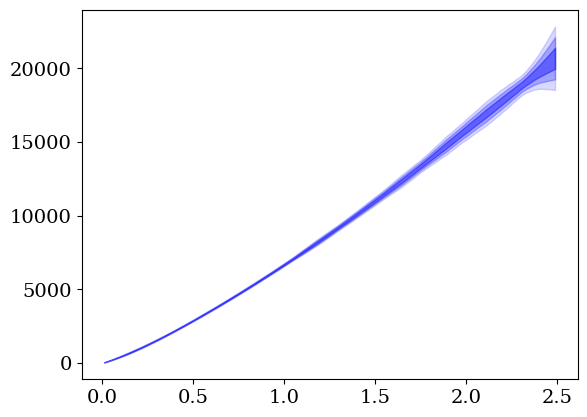

In [ ]:
DL_down_mean = DA_mean*(1+z_plot)**2
DL_down_mean_err = DA_err*(1+z_plot)**2
for sigma, alpha_fill, label_fill in zip([1, 2, 3], [0.4, 0.25, 0.15],[r'68% CI ($\pm 1\sigma$)', r'95% CI ($\pm 2\sigma$)', r'99.7% CI ($\pm 3\sigma$)']):
        plt.fill_between(z_plot,
                (DL_down_mean - sigma * DL_down_mean_err),
                (DL_down_mean + sigma * DL_down_mean_err),
                color='blue', alpha=alpha_fill, label=label_fill)

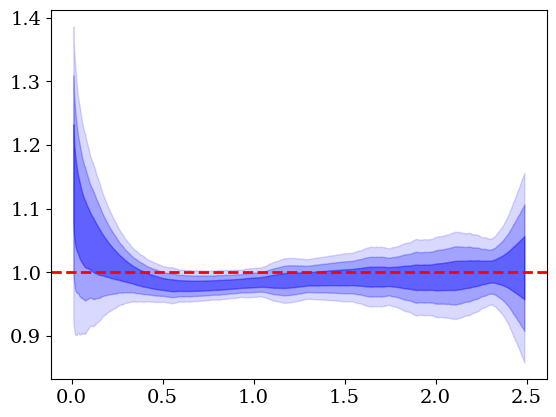

In [26]:
eta_mean = DL_mean/DL_down_mean
eta_err = eta_mean *np.sqrt((DA_err/DA_mean)**2+(DL_down_mean_err/DL_down_mean)**2)
for sigma, alpha_fill, label_fill in zip([1, 2, 3], [0.4, 0.25, 0.15],[r'68% CI ($\pm 1\sigma$)', r'95% CI ($\pm 2\sigma$)', r'99.7% CI ($\pm 3\sigma$)']):
        plt.fill_between(z_plot,
                (eta_mean - sigma * eta_err),
                (eta_mean + sigma * eta_err),
                color='blue', alpha=alpha_fill, label=label_fill)
plt.axhline(1.0, color='red', linestyle='--', linewidth=2, label=r'CDDR ($\eta=1$)')

In [22]:
eta_mean

array([1.15275146, 1.1362956 , 1.12525686, 1.11720384, 1.11095341,
       1.10586824, 1.10159529, 1.09783   , 1.09443709, 1.09128245,
       1.08839573, 1.08568693, 1.08309258, 1.08059709, 1.07820279,
       1.0758844 , 1.07366816, 1.07157711, 1.06959289, 1.06770217,
       1.06592353, 1.06426134, 1.06270717, 1.0612452 , 1.0598729 ,
       1.05859855, 1.05740406, 1.05628201, 1.0552096 , 1.0541682 ,
       1.05314045, 1.05213607, 1.05114336, 1.05015884, 1.04917507,
       1.04820106, 1.04722717, 1.04626004, 1.04529924, 1.04434119,
       1.04339111, 1.0424506 , 1.04152558, 1.04059747, 1.03967684,
       1.03877372, 1.03788575, 1.03700779, 1.03614339, 1.03528429,
       1.03444752, 1.03362467, 1.03281937, 1.03202827, 1.03124859,
       1.03048708, 1.02974459, 1.02901798, 1.02829326, 1.02758075,
       1.02688375, 1.02619705, 1.02551477, 1.02483907, 1.0241751 ,
       1.02350778, 1.02284789, 1.02219797, 1.02155606, 1.02092451,
       1.02029706, 1.01967735, 1.01906564, 1.01845659, 1.01785


Processing prior: Planck2018MB0


/home/zxw/work/CDDR_Test/.venv/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:526: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  y_samples = rng.multivariate_normal(y_mean, y_cov, n_samples).T


chi2: 137.34, p-value: 0.0000
Number of BAO points: 11


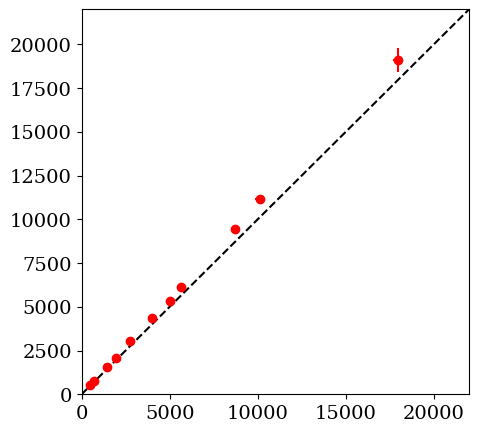

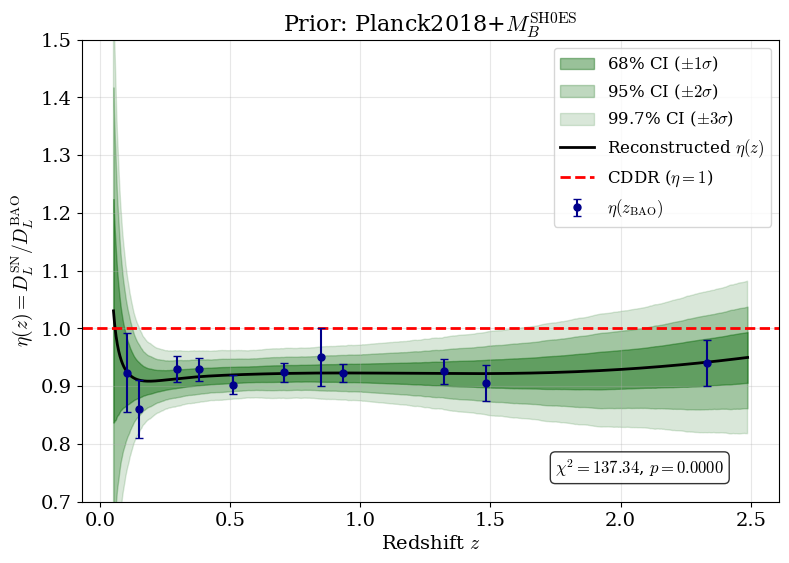

BAO information
BAO point 1: z=0.106, η=0.9233 ± 0.0682
BAO point 2: z=0.150, η=0.8609 ± 0.0504
BAO point 3: z=0.295, η=0.9290 ± 0.0225
BAO point 4: z=0.380, η=0.9292 ± 0.0197
BAO point 5: z=0.510, η=0.9029 ± 0.0162
BAO point 6: z=0.706, η=0.9242 ± 0.0161
BAO point 7: z=0.850, η=0.9507 ± 0.0509
BAO point 8: z=0.934, η=0.9230 ± 0.0162
BAO point 9: z=1.321, η=0.9256 ± 0.0214
BAO point 10: z=1.484, η=0.9058 ± 0.0305
BAO point 11: z=2.330, η=0.9401 ± 0.0393

Processing prior: Planck2018MB23


/home/zxw/work/CDDR_Test/.venv/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:526: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  y_samples = rng.multivariate_normal(y_mean, y_cov, n_samples).T


chi2: 7.85, p-value: 0.7266
Number of BAO points: 11


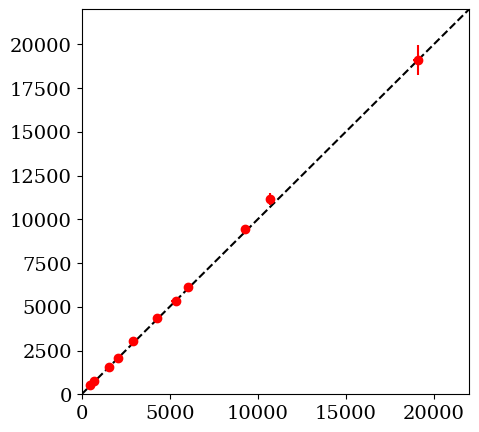

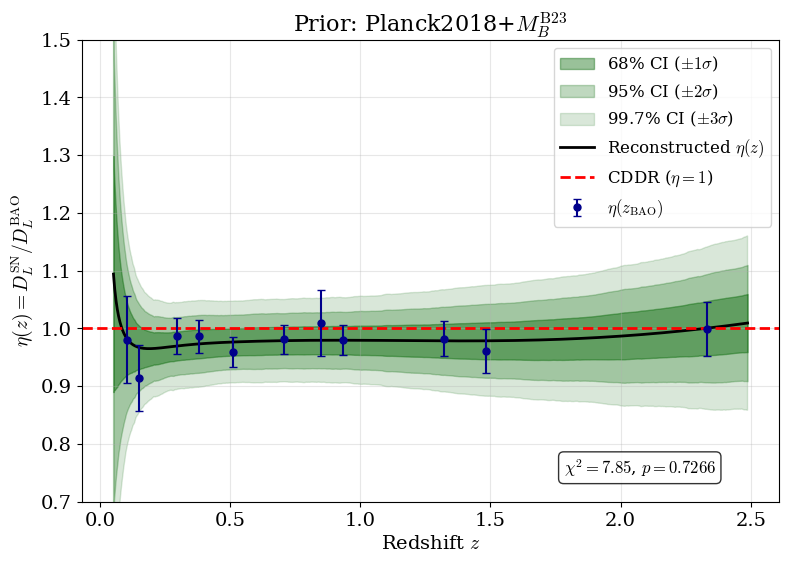

BAO information
BAO point 1: z=0.106, η=0.9806 ± 0.0749
BAO point 2: z=0.150, η=0.9143 ± 0.0565
BAO point 3: z=0.295, η=0.9866 ± 0.0310
BAO point 4: z=0.380, η=0.9868 ± 0.0286
BAO point 5: z=0.510, η=0.9588 ± 0.0258
BAO point 6: z=0.706, η=0.9812 ± 0.0257
BAO point 7: z=0.850, η=1.0092 ± 0.0574
BAO point 8: z=0.934, η=0.9797 ± 0.0255
BAO point 9: z=1.321, η=0.9825 ± 0.0307
BAO point 10: z=1.484, η=0.9616 ± 0.0380
BAO point 11: z=2.330, η=0.9988 ± 0.0466


In [ ]:
priors = [
    {"name":"Planck2018MB0", "label":"Planck2018+$M_B^\\mathrm{SH0ES}$", "MB": -19.253, "MB_err": 0.027, "rd": 147.09, "rd_err": 0.26},
    # {"name":"Planck2018MB23", "label":"Planck2018+$M_B^\\text{B23}$", "MB": -19.396, "MB_err": 0.0404, "rd": 147.09, "rd_err": 0.26},
    {"name":"Planck2018MB23", "label":"Planck2018+$M_B^\\mathrm{B23}$", "MB": -19.384, "MB_err": 0.052, "rd": 147.09, "rd_err": 0.26},
]
z_plot = np.linspace(0.005, max(z_sn) * 1.1, 1000)
n_MC = 1000
z_bao_dv, DV_rd, DV_rd_err = np.loadtxt('data/Combine_DV_rd.dat', unpack=True)
z_bao_dm, DM_rd, DM_rd_err = np.loadtxt('data/Combine_DM_rd.dat', unpack=True)
_, H_dv, H_dv_err = np.loadtxt('output/Hz_DVreconstruct_results.txt', unpack=True)
z_bao = np.concatenate((z_bao_dv, z_bao_dm)) 

# ---------- 主循环（对每个先验） ----------
for prior in priors:
    MB = prior["MB"]; MB_err = prior["MB_err"]
    rd = prior["rd"]; rd_err = prior["rd_err"]
    print(f"\nProcessing prior: {prior['name']}")

    # BAO: 把两种BAO数据转化为 DL
    DL_bao_DV, DL_bao_DV_err = utils.bao_DV_to_DL(z_bao_dv, DV_rd, DV_rd_err, H_dv, H_dv_err, rd, rd_err)
    DL_bao_DM, DL_bao_DM_err = utils.bao_DM_to_DL(z_bao_dm, DM_rd, DM_rd_err, rd, rd_err)

    # 合并 BAO 点（保存原始观测数据）
    DL_bao_obs = np.concatenate((DL_bao_DV, DL_bao_DM))        # BAO观测距离
    DL_bao_obs_err = np.concatenate((DL_bao_DV_err, DL_bao_DM_err)) # BAO观测误差

    # GP拟合BAO数据
    gp_bao = utils.fit_gp_DL(z_bao, DL_bao_obs, DL_bao_obs_err)
    DL_bao_gp_mean, DL_bao_gp_std = gp_bao.predict(z_plot.reshape(-1,1), return_std=True)

    # 从GP中抽取BAO距离样本
    DL_bao_samples = gp_bao.sample_y(z_plot.reshape(-1,1), n_MC).T # 从高斯过程中每个z_plot处抽取n_MC个样本

    # 超新星抽样
    mB_samples = np.random.multivariate_normal(mB_pred_mean, mB_pred_cov, size=n_MC) #通过多元高斯分布抽样得到样本
    MB_samples = np.random.normal(MB, MB_err, n_MC) # 在高斯分布中抽取nMC个MB点

    DL_sn_samples = 10**((mB_samples - MB_samples[:, np.newaxis] - 25) / 5)
    DL_sn_mean = np.mean(DL_sn_samples, axis=0)
    DL_sn_err = 0.5 * (np.percentile(DL_sn_samples, 84, axis=0) - np.percentile(DL_sn_samples, 16, axis=0))


    # 计算在BAO观测红移点上的光度距离
    DL_sn_samples_at_bao = np.array([np.interp(z_bao, z_plot, sample) for sample in DL_sn_samples])
    DL_sn_mean_at_bao = np.mean(DL_sn_samples_at_bao, axis=0)
    DL_sn_err_at_bao = 0.5 * (np.percentile(DL_sn_samples_at_bao, 84, axis=0) - np.percentile(DL_sn_samples_at_bao, 16, axis=0))
    
    # 计算η(z) = SN距离 / BAO距离
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_err = 0.5 * (np.percentile(eta_samples, 84, axis=0) - np.percentile(eta_samples, 16, axis=0))

    # 计算BAO观测点处的η值（用于误差棒）
    eta_match = DL_sn_mean_at_bao / DL_bao_obs
    eta_match_std = np.abs(eta_match) * np.sqrt(
        (DL_sn_err_at_bao / DL_sn_mean_at_bao)**2 + (DL_bao_obs_err / DL_bao_obs)**2
    )

    # 计算chi2
    chi2_val, p_val = utils.eta_chi2(eta_match, eta_match_std)
    print(f"chi2: {chi2_val:.2f}, p-value: {p_val:.4f}")
    print(f"Number of BAO points: {len(z_bao)}")

    plt.figure(figsize=(5,5))
    plt.axline((0, 0), slope=1, linestyle='--', color='k')
    plt.errorbar(DL_sn_mean_at_bao, DL_bao_obs, DL_sn_err_at_bao, DL_bao_obs_err,fmt='o',color='red')
    plt.xlim(0, 22000)
    plt.ylim(0, 22000)
    plt.show()

    # 绘图
    plt.figure(figsize=(9,6))
    mask = z_plot > 0.1
    
    for sigma, alpha_fill, label_fill in zip([1, 2, 3], [0.4, 0.25, 0.15],[r'68% CI ($\pm 1\sigma$)', r'95% CI ($\pm 2\sigma$)', r'99.7% CI ($\pm 3\sigma$)']):
            plt.fill_between(z_plot[mask],
                    (eta_mean - sigma * eta_err)[mask],
                    (eta_mean + sigma * eta_err)[mask],
                    color='darkgreen', alpha=alpha_fill, label=label_fill)
    # 1. η(z)重建曲线
    plt.plot(z_plot[mask], eta_mean[mask], color='black', label=r'Reconstructed $\eta(z)$', linewidth=2)
    # plt.fill_between(z_plot[mask], eta_mean[mask] - eta_err[mask], eta_mean[mask] + eta_err[mask], color='red', alpha=0.3, label=r'1$\sigma$ uncertainty')
    
    # 2. η=1参考线
    plt.axhline(1.0, color='red', linestyle='--', linewidth=2, label=r'CDDR ($\eta=1$)')
    
    # 3. BAO观测点
    # plt.errorbar(z_match, eta_match, yerr=eta_match_std, fmt='o', color='darkblue', capsize=3, markersize=8, label=r'$\eta(z_{\mathrm{BAO}})$', zorder=5)
    plt.errorbar(z_bao, eta_match, yerr=eta_match_std, fmt='o', label=r'$\eta(z_\mathrm{BAO})$', color='darkblue', capsize=3, markersize=5)
    
    # 4. 坐标轴和标题
    plt.xlabel('Redshift $z$', fontsize=14)
    plt.ylabel(r'$\eta(z) = D_L^{\mathrm{SN}} / D_L^{\mathrm{BAO}}$', fontsize=14)
    plt.title(f"Prior: {prior['label']}", fontsize=16)
    plt.ylim(0.7,1.5)
    # 5. 统计信息
    textstr = f'$\\chi^2 = {chi2_val:.2f}$, $p = {p_val:.4f}$'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.8, 0.05, textstr, transform=plt.gca().transAxes, ha='center', va='bottom', fontsize=12, bbox=props)
    
    plt.legend(fontsize=12, loc='best')
    plt.grid(alpha=0.3)
    plt.savefig(rf"fig/eta_GPR_reconstruct_{prior['name']}.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印BAO点信息
    print("BAO information")
    for i, (z, eta, eta_err) in enumerate(zip(z_bao, eta_match, eta_match_std)):
        print(rf"BAO point {i+1}: z={z:.3f}, η={eta:.4f} ± {eta_err:.4f}")

--------------------

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import utils

def matern_kernel(x1, x2, nu, l=0.1, sigma_f=1.0):
    x1 = np.atleast_2d(x1).T if np.ndim(x1) == 1 else np.atleast_2d(x1)
    x2 = np.atleast_2d(x2)

    d = np.abs(x1 - x2)

    if np.isclose(nu, 0.5):
        K = sigma_f**2 * np.exp(-d / l)

    elif np.isclose(nu, 1.5):
        sqrt3 = np.sqrt(3.0)
        K = sigma_f**2 * (1 + sqrt3 * d / l) * np.exp(-sqrt3 * d / l)

    elif np.isclose(nu, 2.5):
        sqrt5 = np.sqrt(5.0)
        K = sigma_f**2 * (
            1 + sqrt5 * d / l + 5.0 * d**2 / (3.0 * l**2)
        ) * np.exp(-sqrt5 * d / l)

    else:
        from scipy.special import gamma, kv
        d_safe = np.maximum(d, 1e-12)
        arg = np.sqrt(2 * nu) * d_safe / l
        factor = (2**(1. - nu)) / gamma(nu)
        K = sigma_f**2 * factor * (arg**nu) * kv(nu, arg)
        K[d == 0.0] = sigma_f**2

    return K


def gp_predict(z_obs, y_obs, cov_obs, z_predict, kernel_func, nu, l=0.1, sigma_f=1.0):
    K = kernel_func(z_obs, z_obs, nu, l=l, sigma_f=sigma_f)
    K_s = kernel_func(z_predict, z_obs, nu, l=l, sigma_f=sigma_f)
    K_ss = kernel_func(z_predict, z_predict, nu, l=l, sigma_f=sigma_f)

    A = K + cov_obs
    
    A += 1e-8 * np.eye(len(A))
    
    L = np.linalg.cholesky(A)
    
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_obs))
    y_mean = K_s @ alpha
    
    v = np.linalg.solve(L, K_s.T)
    y_cov = K_ss - v.T @ v
    
    return y_mean, y_cov

In [8]:
import emcee

# 1. 定义趋势函数（用于去趋势）
def mb_trend(z):
    return 5 * np.log10(z) + 25  # 这是一个近似的物理背景

# 2. 准备数据：对数化坐标 + 去趋势
z_bao_dv, DV_rd, DV_rd_err = np.loadtxt('data/Combine_DV_rd.dat', unpack=True)
z_bao_dm, DM_rd, DM_rd_err = np.loadtxt('data/Combine_DM_rd.dat', unpack=True)
_, H_dv, H_dv_err = np.loadtxt('output/Hz_DVreconstruct_results.txt', unpack=True)
z_bao = np.concatenate((z_bao_dv, z_bao_dm))
sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
mB_obs = sn_df['m_b_corr'].values
z_match = z_bao



cov_full = utils.read_cov('data/Pantheon+SH0ES_STAT+SYS.cov')
mB_obs_std = np.sqrt(np.diag(cov_full))

log_z_sn = np.log10(z_sn)
y_residual_sn = mB_obs - mb_trend(z_sn)
log_z_match = np.log10(z_match)

def log_posterior(theta, z_obs, y_obs, cov_obs, kernel, nu):
    log_l, log_sigma_f = theta

    l = np.exp(log_l)
    sigma_f = np.exp(log_sigma_f)

    K = kernel(z_obs, z_obs, nu, l=l, sigma_f=sigma_f)
    A = K + cov_obs + 1e-8 * np.eye(len(z_obs))
    L = np.linalg.cholesky(A)

    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_obs))

    loglikelihood = (-0.5 * y_obs @ alpha - np.sum(np.log(np.diag(L))) - 0.5 * len(z_obs) * np.log(2*np.pi))

    logprior = (-0.5 * (log_l / 1.0)**2 - 0.5 * (log_sigma_f / 1.0)**2)

    return loglikelihood + logprior

def run_mcmc(z_obs, y_res, cov_obs, kernel, nu, nwalkers=32, nsteps=2000, burnin=500, log_posterior=log_posterior):
    ndim = 2
    p0 = np.zeros((nwalkers, ndim))
    p0[:, 0] = np.random.normal(np.log(0.2), 0.1, nwalkers)  # log l
    p0[:, 1] = np.random.normal(np.log(0.5), 0.1, nwalkers)  # log sigma_f

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(z_obs, y_res, cov_obs, kernel, nu))
    sampler.run_mcmc(p0, nsteps, progress=True)
    return sampler.get_chain(discard=burnin, flat=True), sampler

def gp_predict_marginalized(z_obs, y_res, cov_obs, z_predict, theta_samples, trend_func, thin, kernel, nu):
    means = []
    covs  = []
    
    z_predict_phys = 10**z_predict 
    trend_at_predict = trend_func(z_predict_phys)

    for theta in theta_samples[::thin]:
        l = np.exp(theta[0])
        sigma_f = np.exp(theta[1])

        mu_s, cov_s = gp_predict(z_obs, y_res, cov_obs, z_predict, kernel, nu, l=l, sigma_f=sigma_f)
        
        means.append(mu_s + trend_at_predict)
        covs.append(cov_s)

    means = np.array(means)
    covs  = np.array(covs)

    mean_final = np.mean(means, axis=0)
    cov_final = np.mean(covs, axis=0) + np.cov(means.T)

    return mean_final, cov_final

In [5]:
theta_samples, sampler = run_mcmc(log_z_sn, y_residual_sn, cov_full, kernel=matern_kernel, nu=3/2)

mB_match, mB_match_cov = gp_predict_marginalized(
    log_z_sn, y_residual_sn, cov_full,
    log_z_match,
    theta_samples,
    trend_func = mb_trend,
    thin=10,
    kernel = matern_kernel,
    nu=3/2
)

100%|██████████| 2000/2000 [2:54:25<00:00,  5.23s/it]  


In [6]:
tau = sampler.get_autocorr_time(tol=0)
print("Integrated autocorr time:", tau)
print("Steps / tau:", sampler.iteration / tau)


Integrated autocorr time: [30.31682748 30.0780285 ]
Steps / tau: [65.96996343 66.49371983]


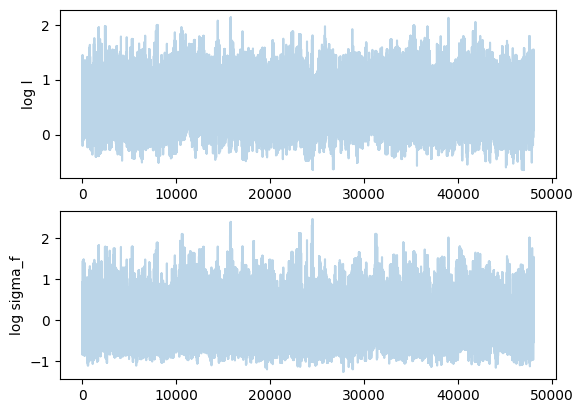

In [14]:
import matplotlib.pyplot as plt
theta_samples.shape
plt.figure()
for i, label in enumerate(["log l", "log sigma_f"]):
    plt.subplot(2, 1, i+1)
    plt.plot(theta_samples[:, i], alpha=0.3)
    plt.ylabel(label)
plt.show()

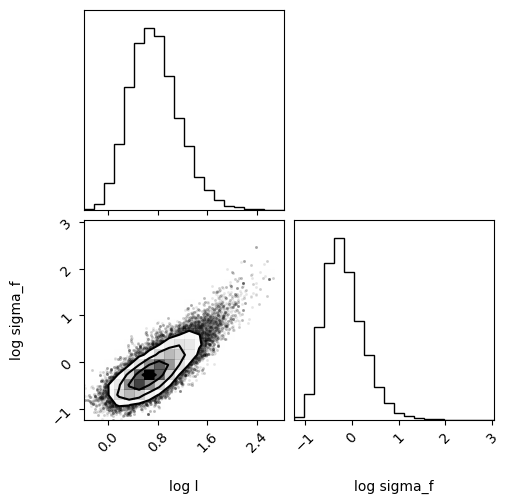

log l 0.7531741743773094
log sigma_f -0.16370176518527915


In [7]:
import corner

corner.corner(theta_samples, labels=["log l", "log sigma_f"])
plt.show()
for i, label in enumerate(["log l", "log sigma_f"]):
    print(label, np.mean(theta_samples[:, i]))

In [ ]:
np.save("output/theta_samples.npy", theta_samples)
np.save("output/mB_match_GPR.npy", mB_match)
np.save("output/mB_match_GPR_cov.npy", mB_match_cov)

In [8]:
mB_match_std = np.sqrt(np.diag(mB_match_cov))
print(mB_match)
print(mB_match_std)

[19.09111105 19.8866267  21.54765351 22.17879259 22.9140231  23.76346031
 24.2756345  24.5424439  25.49995749 25.80551023 26.94720071]
[0.01697096 0.01225931 0.00969456 0.01076902 0.01360057 0.0177987
 0.02490224 0.03124744 0.05009433 0.05512708 0.10234694]


Start reconstruction using 100 samples...


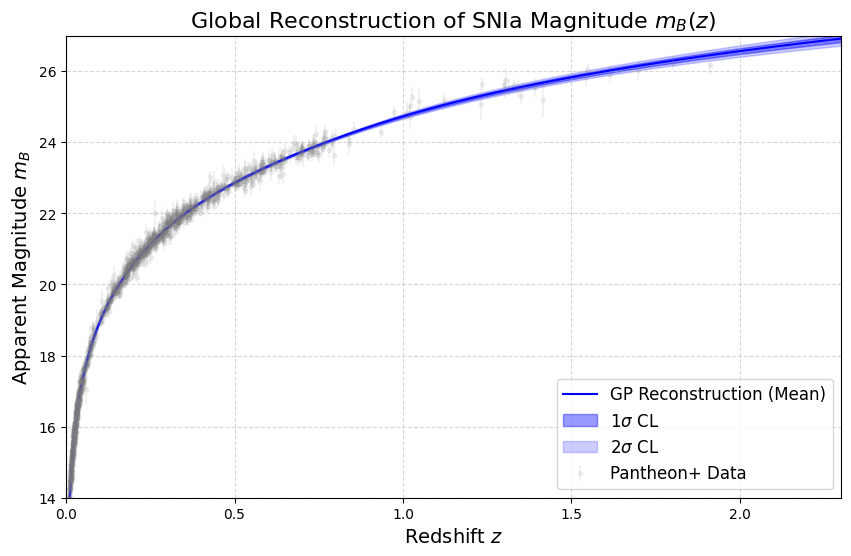

In [ ]:
# theta_samples = np.load("output/theta_samples.npy")
z_min = 0.01  # 或者 0.01
z_max = 2.3           #稍微超过数据范围一点
n_points = 200        # 点越多曲线越平滑，但计算越慢

z_plot = np.linspace(z_min, z_max, n_points)
log_z_plot = np.log10(z_plot)  # 转换到对数空间

# ==========================================
# 2. 修改后的预测函数 (针对绘图优化)
# ==========================================
def gp_predict_global(z_obs, y_res, cov_obs, z_plot_log, theta_samples, trend_func, kernel, nu, thin=10):
    """
    专门用于全局重构。
    为了节省内存和计算量，这里我们只计算对角线方差（画图只需要误差带，不需要全协方差矩阵）。
    """
    means = []
    variances = [] # 存储方差而不是全矩阵
    
    # 计算画图点的物理趋势
    z_plot_phys = 10**z_plot_log
    trend_at_plot = trend_func(z_plot_phys)

    # 遍历 MCMC 样本 (Thinning 减少计算量)
    # 建议 thin 设大一点，比如 len(chain) // 100，取100个样本足够画图了
    step = max(1, len(theta_samples) // 100) 
    
    print(f"Start reconstruction using {len(theta_samples[::step])} samples...")

    for theta in theta_samples[::step]:
        l = np.exp(theta[0])
        sigma_f = np.exp(theta[1])

        # GP 预测 (获取均值和协方差)
        # 注意：这里调用你之前的 gp_predict
        mu_s, cov_s = gp_predict(z_obs, y_res, cov_obs, z_plot_log, kernel, nu, l=l, sigma_f=sigma_f)
        
        # 记录结果 (加上趋势)
        means.append(mu_s + trend_at_plot)
        variances.append(np.diag(cov_s)) # 只取对角线

    means = np.array(means)         # Shape: (N_samples, N_plot)
    variances = np.array(variances) # Shape: (N_samples, N_plot)

    # === 贝叶斯全方差公式 ===
    # 1. 均值的期望
    final_mean = np.mean(means, axis=0)
    
    # 2. 方差 = (方差的均值) + (均值的方差)
    # Data Noise term + Parameter Uncertainty term
    mean_of_variances = np.mean(variances, axis=0)
    variance_of_means = np.var(means, axis=0)
    
    final_std = np.sqrt(mean_of_variances + variance_of_means)

    return final_mean, final_std

# ==========================================
# 3. 执行重构
# ==========================================
# 确保传入的是训练用的对数坐标数据
rec_mean, rec_std = gp_predict_global(
    log_z_sn,          # 训练数据 x (log)
    y_residual_sn,     # 训练数据 y (residual)
    cov_full,          # 训练数据 cov
    log_z_plot,        # 预测网格 (log)
    theta_samples,     # MCMC 链
    mb_trend,          # 趋势函数
    matern_kernel,
    3/2
)

# ==========================================
# 4. 画图 (Matplotlib)
# ==========================================
plt.figure(figsize=(10, 6))

# 画原始数据
plt.errorbar(z_sn, mB_obs, yerr=mB_obs_std, fmt='.', color='gray', alpha=0.1, label='Pantheon+ Data')

# 画 GP 重构结果
plt.plot(z_plot, rec_mean, color='blue', label='GP Reconstruction (Mean)')

# 画 1-sigma 误差带 (68%)
plt.fill_between(z_plot, 
                 rec_mean - rec_std, 
                 rec_mean + rec_std, 
                 color='blue', alpha=0.4, label=r'$1\sigma$ CL')

# 画 2-sigma 误差带 (95%)
plt.fill_between(z_plot, 
                 rec_mean - 2*rec_std, 
                 rec_mean + 2*rec_std, 
                 color='blue', alpha=0.2, label=r'$2\sigma$ CL')

plt.xlabel('Redshift $z$', fontsize=14)
plt.ylabel('Apparent Magnitude $m_B$', fontsize=14)
plt.title('Global Reconstruction of SNIa Magnitude $m_B(z)$', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 坐标轴调整 (根据需要)
plt.xlim(0, 2.3)
plt.ylim(14, 27) # 根据数据范围大致调整

plt.show()

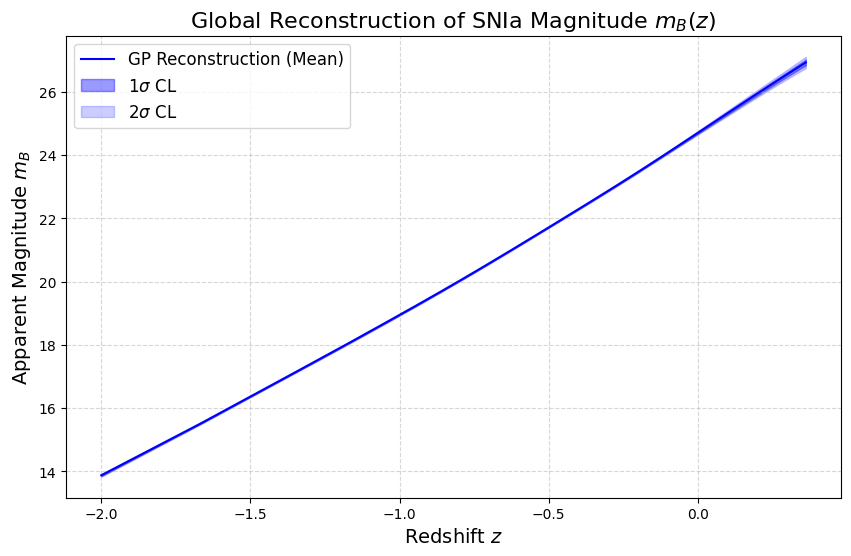

In [8]:
plt.figure(figsize=(10, 6))

# 画原始数据 (可选，数据点太多可能看不清，可以画一部分或不画)
# plt.errorbar(z_sn, mB_obs, yerr=mB_obs_std, fmt='.', color='gray', alpha=0.1, label='Pantheon+ Data')

# 画 GP 重构结果
plt.plot(np.log10(z_plot), rec_mean, color='blue', label='GP Reconstruction (Mean)')

# 画 1-sigma 误差带 (68%)
plt.fill_between(np.log10(z_plot), 
                 rec_mean - rec_std, 
                 rec_mean + rec_std, 
                 color='blue', alpha=0.4, label=r'$1\sigma$ CL')

# 画 2-sigma 误差带 (95%)
plt.fill_between(np.log10(z_plot), 
                 rec_mean - 2*rec_std, 
                 rec_mean + 2*rec_std, 
                 color='blue', alpha=0.2, label=r'$2\sigma$ CL')

plt.xlabel('Redshift $z$', fontsize=14)
plt.ylabel('Apparent Magnitude $m_B$', fontsize=14)
plt.title('Global Reconstruction of SNIa Magnitude $m_B(z)$', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)



plt.show()

后面的是过去的代码残留

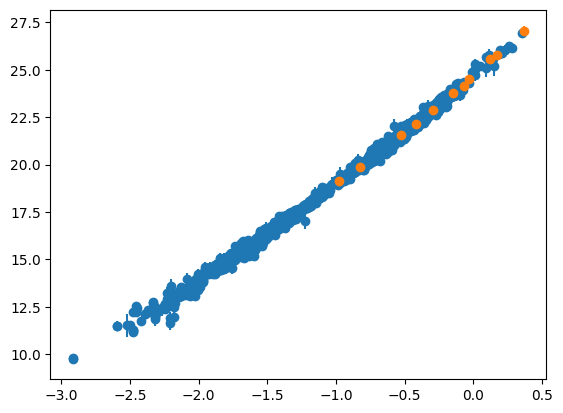

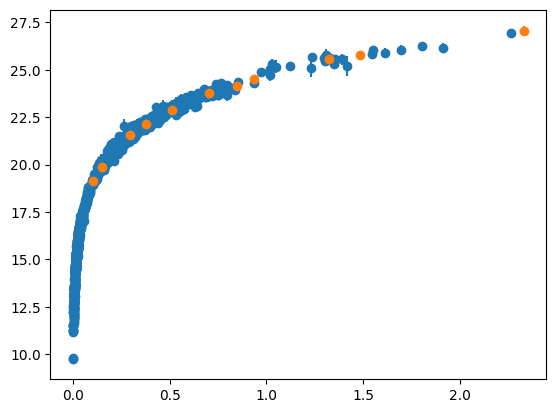

In [ ]:
import utils
z_bao_dv, DV_rd, DV_rd_err = np.loadtxt('data/Combine_DV_rd.dat', unpack=True)
z_bao_dm, DM_rd, DM_rd_err = np.loadtxt('data/Combine_DM_rd.dat', unpack=True)
_, H_dv, H_dv_err = np.loadtxt('output/Hz_DVreconstruct_results.txt', unpack=True)
z_bao = np.concatenate((z_bao_dv, z_bao_dm)) 
sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
mB_obs = sn_df['m_b_corr'].values
with open('data/Pantheon+SH0ES_STAT+SYS.cov', 'r') as f:
    lines = f.readlines()
N_cov = int(lines[0].strip())
cov_vec = np.array([float(x.strip()) for x in lines[1:]])
cov_full = cov_vec.reshape((N_cov, N_cov))
cov_inv = np.linalg.inv(cov_full)
mB_obs_std = np.sqrt(np.diag(cov_full))

# 1. 定义一个简单的趋势函数 (可以是 5log10z + 常数)
def mb_trend(z):
    return 5 * np.log10(z) + 25 # 25 是一个大致的平移量

# 2. 计算训练数据和预测数据的趋势
trend_sn = mb_trend(z_sn)
trend_bao = mb_trend(z_bao)

# 3. 让 GP 拟合残差 (mB - trend)
y_residual = mB_obs - trend_sn

# 4. 运行 GP 预测残差
res_mean, res_cov = gp_predict(np.log10(z_sn), y_residual, cov_full, np.log10(z_bao), matern_kernel)

# 5. 将预测出的残差加回趋势，得到最终结果
mB_match = res_mean + trend_bao
mB_match_cov = res_cov
mB_match_std = np.sqrt(np.diag(mB_match_cov))

import matplotlib.pyplot as plt
plt.errorbar(np.log10(z_sn), mB_obs, mB_obs_std, fmt = 'o')
plt.errorbar(np.log10(z_bao), mB_match, mB_match_std, fmt = 'o')
plt.show()

plt.errorbar(z_sn, mB_obs, mB_obs_std, fmt = 'o')
plt.errorbar(z_bao, mB_match, mB_match_std, fmt = 'o')
plt.show()


In [5]:
def gp_log_marginal_likelihood(z_obs, y_obs, cov_obs, kernel_func, l, sigma_f):
    # 核矩阵
    K = kernel_func(z_obs, z_obs, l=l, sigma_f=sigma_f)
    A = K + cov_obs

    # jitter
    A += 1e-8 * np.eye(len(A))

    # Cholesky
    L = np.linalg.cholesky(A)

    # 解 A^{-1} y
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_obs))

    # 计算 log |A| = 2 * sum(log(diag(L)))
    logdetA = 2.0 * np.sum(np.log(np.diag(L)))

    n = len(y_obs)

    lml = (
        -0.5 * y_obs.T @ alpha
        -0.5 * logdetA
        -0.5 * n * np.log(2 * np.pi)
    )

    return lml

from scipy.optimize import minimize

def neg_log_marginal_likelihood(theta, z_obs, y_obs, cov_obs, kernel_func):
    # 用 log 参数保证正性
    log_l, log_sigma_f = theta
    l = np.exp(log_l)
    sigma_f = np.exp(log_sigma_f)

    lml = gp_log_marginal_likelihood(
        z_obs, y_obs, cov_obs, kernel_func, l, sigma_f
    )

    return -lml   # minimize → 负对数边际似然


# 初值（你可以微调）
theta0 = np.log([0.3, 1.0])  # log(l), log(sigma_f)

res = minimize(
    neg_log_marginal_likelihood,
    theta0,
    args=(np.log10(z_sn), y_residual, cov_full, matern_kernel),
    method="L-BFGS-B"
)

log_l_opt, log_sigma_f_opt = res.x
l_opt = np.exp(log_l_opt)
sigma_f_opt = np.exp(log_sigma_f_opt)

print("Optimized l =", l_opt)
print("Optimized sigma_f =", sigma_f_opt)
print("Max log marginal likelihood =", -res.fun)


Optimized l = 1.8991585682859458
Optimized sigma_f = 0.8506541043216731
Max log marginal likelihood = 784.678104537777


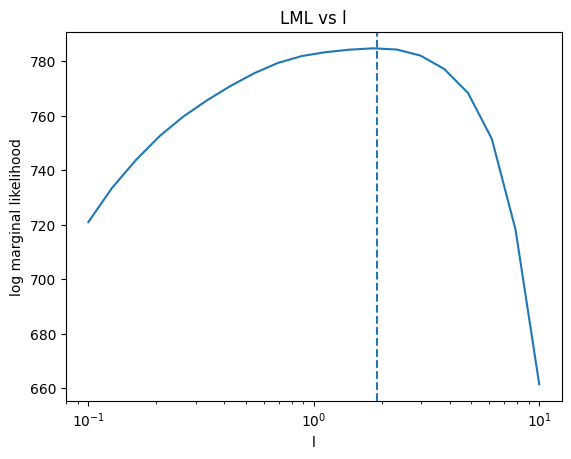

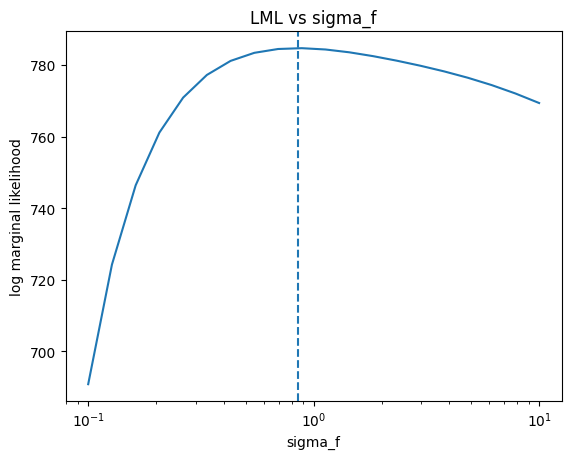

In [7]:
# 扫描范围
l_vals = np.logspace(-1, 1, 20)
sigma_f_vals = np.logspace(-1, 1, 20)

lml_l = []
for l in l_vals:
    lml = gp_log_marginal_likelihood(
        np.log10(z_sn), y_residual, cov_full,
        matern_kernel, l=l, sigma_f=sigma_f_opt
    )
    lml_l.append(lml)

lml_sigma = []
for s in sigma_f_vals:
    lml = gp_log_marginal_likelihood(
        np.log10(z_sn), y_residual, cov_full,
        matern_kernel, l=l_opt, sigma_f=s
    )
    lml_sigma.append(lml)

plt.figure()
plt.semilogx(l_vals, lml_l)
plt.axvline(l_opt, ls="--")
plt.xlabel("l")
plt.ylabel("log marginal likelihood")
plt.title("LML vs l")
plt.show()

plt.figure()
plt.semilogx(sigma_f_vals, lml_sigma)
plt.axvline(sigma_f_opt, ls="--")
plt.xlabel("sigma_f")
plt.ylabel("log marginal likelihood")
plt.title("LML vs sigma_f")
plt.show()


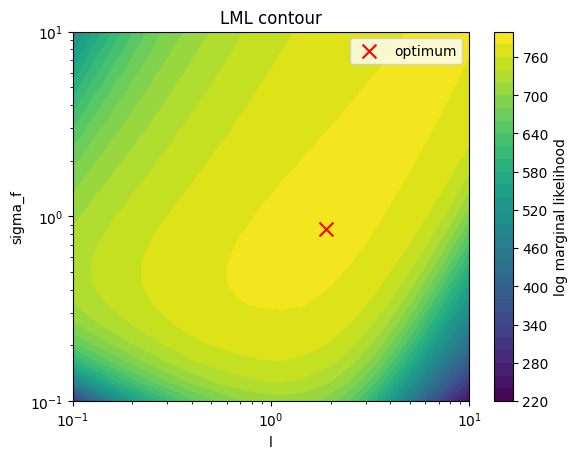

In [8]:
L, S = np.meshgrid(l_vals, sigma_f_vals)
LML = np.zeros_like(L)

for i in range(len(sigma_f_vals)):
    for j in range(len(l_vals)):
        LML[i, j] = gp_log_marginal_likelihood(
            np.log10(z_sn),
            y_residual,
            cov_full,
            matern_kernel,
            l=l_vals[j],
            sigma_f=sigma_f_vals[i]
        )

plt.figure()
cs = plt.contourf(L, S, LML, levels=30)
plt.colorbar(cs, label="log marginal likelihood")
plt.scatter(l_opt, sigma_f_opt, c="r", marker="x", s=100, label="optimum")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("l")
plt.ylabel("sigma_f")
plt.legend()
plt.title("LML contour")
plt.show()


In [9]:
print(l_opt, sigma_f_opt)

1.8991585682859458 0.8506541043216731


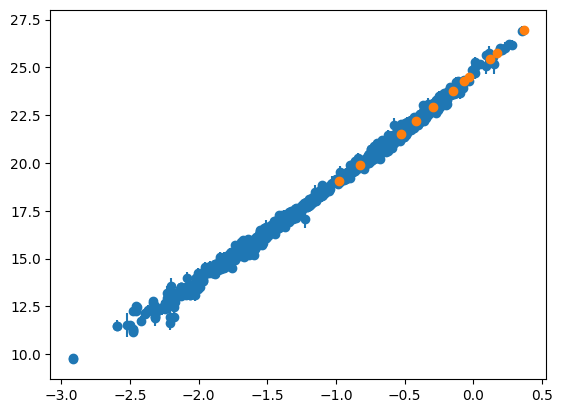

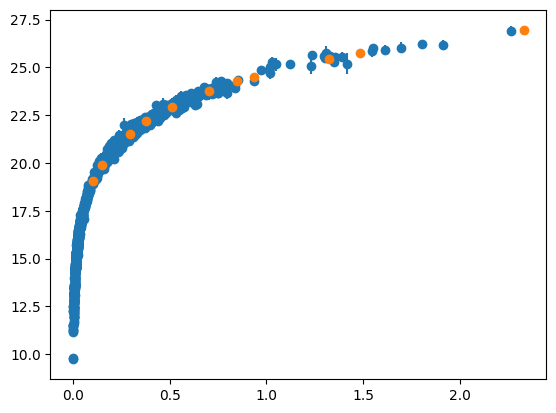

0.106      | 19.0822      | 0.0109    
0.150      | 19.8929      | 0.0091    
0.295      | 21.5425      | 0.0074    
0.380      | 22.1768      | 0.0082    
0.510      | 22.9246      | 0.0105    
0.706      | 23.7718      | 0.0145    
0.850      | 24.2655      | 0.0187    
0.934      | 24.5182      | 0.0215    
1.321      | 25.4530      | 0.0371    
1.484      | 25.7663      | 0.0445    
2.330      | 26.9668      | 0.0847    


In [11]:
import utils
z_bao_dv, DV_rd, DV_rd_err = np.loadtxt('data/Combine_DV_rd.dat', unpack=True)
z_bao_dm, DM_rd, DM_rd_err = np.loadtxt('data/Combine_DM_rd.dat', unpack=True)
_, H_dv, H_dv_err = np.loadtxt('output/Hz_DVreconstruct_results.txt', unpack=True)
z_bao = np.concatenate((z_bao_dv, z_bao_dm)) 

sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
mB_obs = sn_df['m_b_corr'].values

with open('data/Pantheon+SH0ES_STAT+SYS.cov', 'r') as f:
    lines = f.readlines()
N_cov = int(lines[0].strip())
cov_vec = np.array([float(x.strip()) for x in lines[1:]])
cov_full = cov_vec.reshape((N_cov, N_cov))
cov_inv = np.linalg.inv(cov_full)
mB_obs_std = np.sqrt(np.diag(cov_full))

# 1. 定义一个简单的趋势函数 (可以是 5log10z + 常数)
def mb_trend(z):
    return 5 * np.log10(z) + 25 # 25 是一个大致的平移量

# 2. 计算训练数据和预测数据的趋势
trend_sn = mb_trend(z_sn)
trend_bao = mb_trend(z_bao)

# 3. 让 GP 拟合残差 (mB - trend)
y_residual = mB_obs - trend_sn

# 4. 运行 GP 预测残差
res_mean, res_cov = gp_predict(np.log10(z_sn), y_residual, cov_full, np.log10(z_bao), matern_kernel, l=l_opt, sigma_f=sigma_f_opt)

# 5. 将预测出的残差加回趋势，得到最终结果
mB_match = res_mean + trend_bao
mB_match_cov = res_cov
mB_match_std = np.sqrt(np.diag(mB_match_cov))

import matplotlib.pyplot as plt
plt.errorbar(np.log10(z_sn), mB_obs, mB_obs_std, fmt = 'o')
plt.errorbar(np.log10(z_bao), mB_match, mB_match_std, fmt = 'o')
plt.show()

plt.errorbar(z_sn, mB_obs, mB_obs_std, fmt = 'o')
plt.errorbar(z_bao, mB_match, mB_match_std, fmt = 'o')
plt.show()
z_match=z_bao
for z, m, s in zip(z_match, mB_match, mB_match_std):
    print(f"{z:<10.3f} | {m:<12.4f} | {s:<10.4f}")